In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import stats
import pickle
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [11]:
mask= (
    ((dataset.data.index > datetime.datetime(2024, 9, 15)) & (dataset.data.index < datetime.datetime(2024, 10, 15)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [12]:
pump_diff = sensorClasses.Sensor(dataset, id=1048)

# Pump Different Pressure

The goal of this script is to analyze the effect of the value of the pump differential pressure has on the temperature profiles and on the bulk temperature

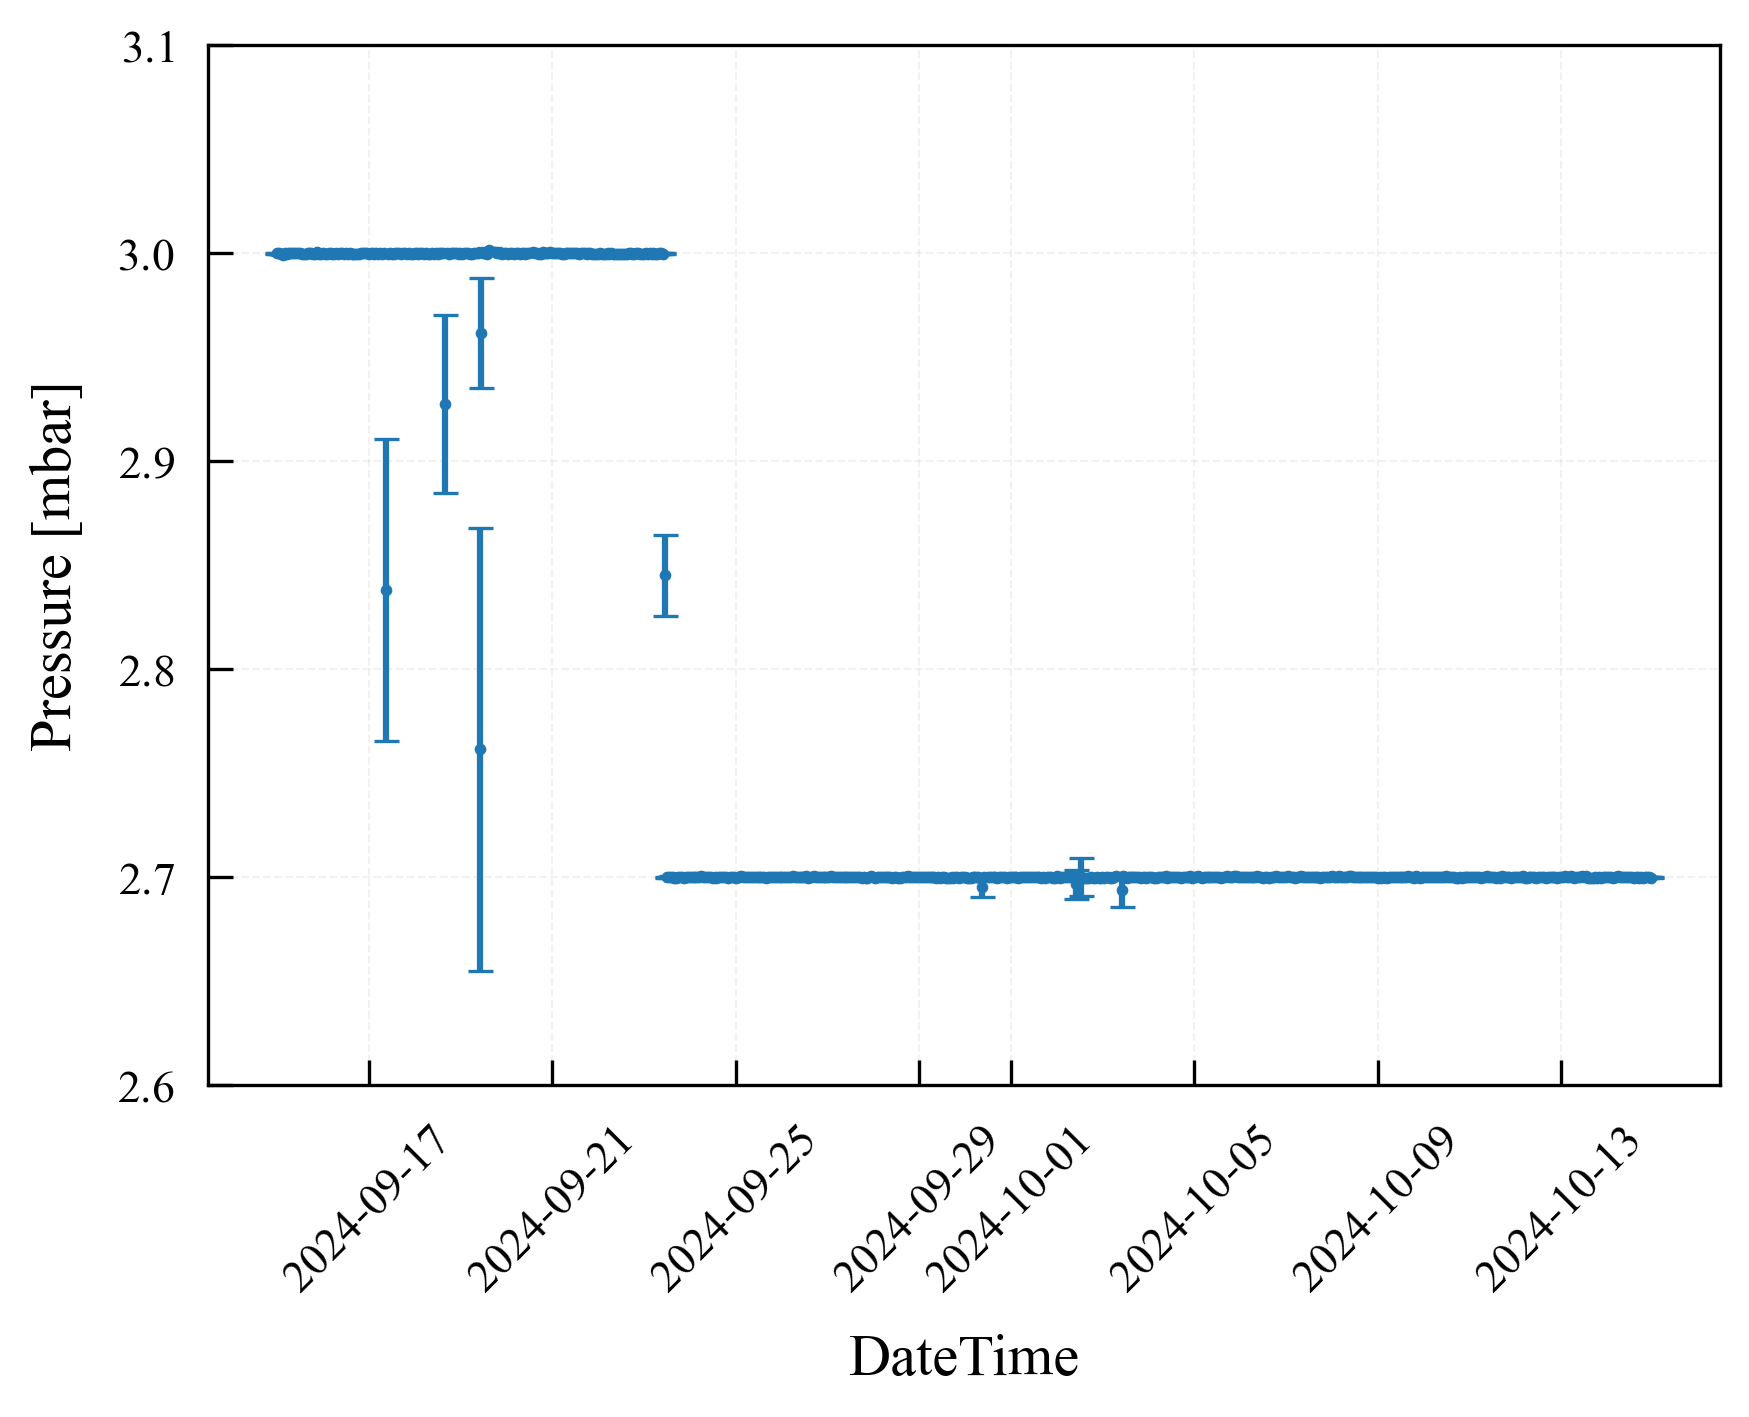

In [ ]:
fig, axes = plt.subplots(1,1)
axes.errorbar(pump_diff.data.resample("60min").mean().index.values, pump_diff.data.resample("60min").mean().values, yerr=pump_diff.data.resample("60min").sem().values, marker=".", linestyle="None")
axes.set_xlabel("DateTime")
axes.set_ylabel("Pressure [bar]")
axes.set_ylim(2.6, 3.1)
# axes.set_xlim(datetime.datetime(2024, 9, 15), datetime.datetime(2024, 10, 1))
axes.tick_params(axis="x", rotation=45)

In [ ]:
tgrad = systemClasses.System(dataset, "TGRAD")
tgrad.calibrate("SECOND_POFF_OCTOBER")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.72sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 98.55sensor/s] 


Text(0, 0.5, 'Temperature [K]')

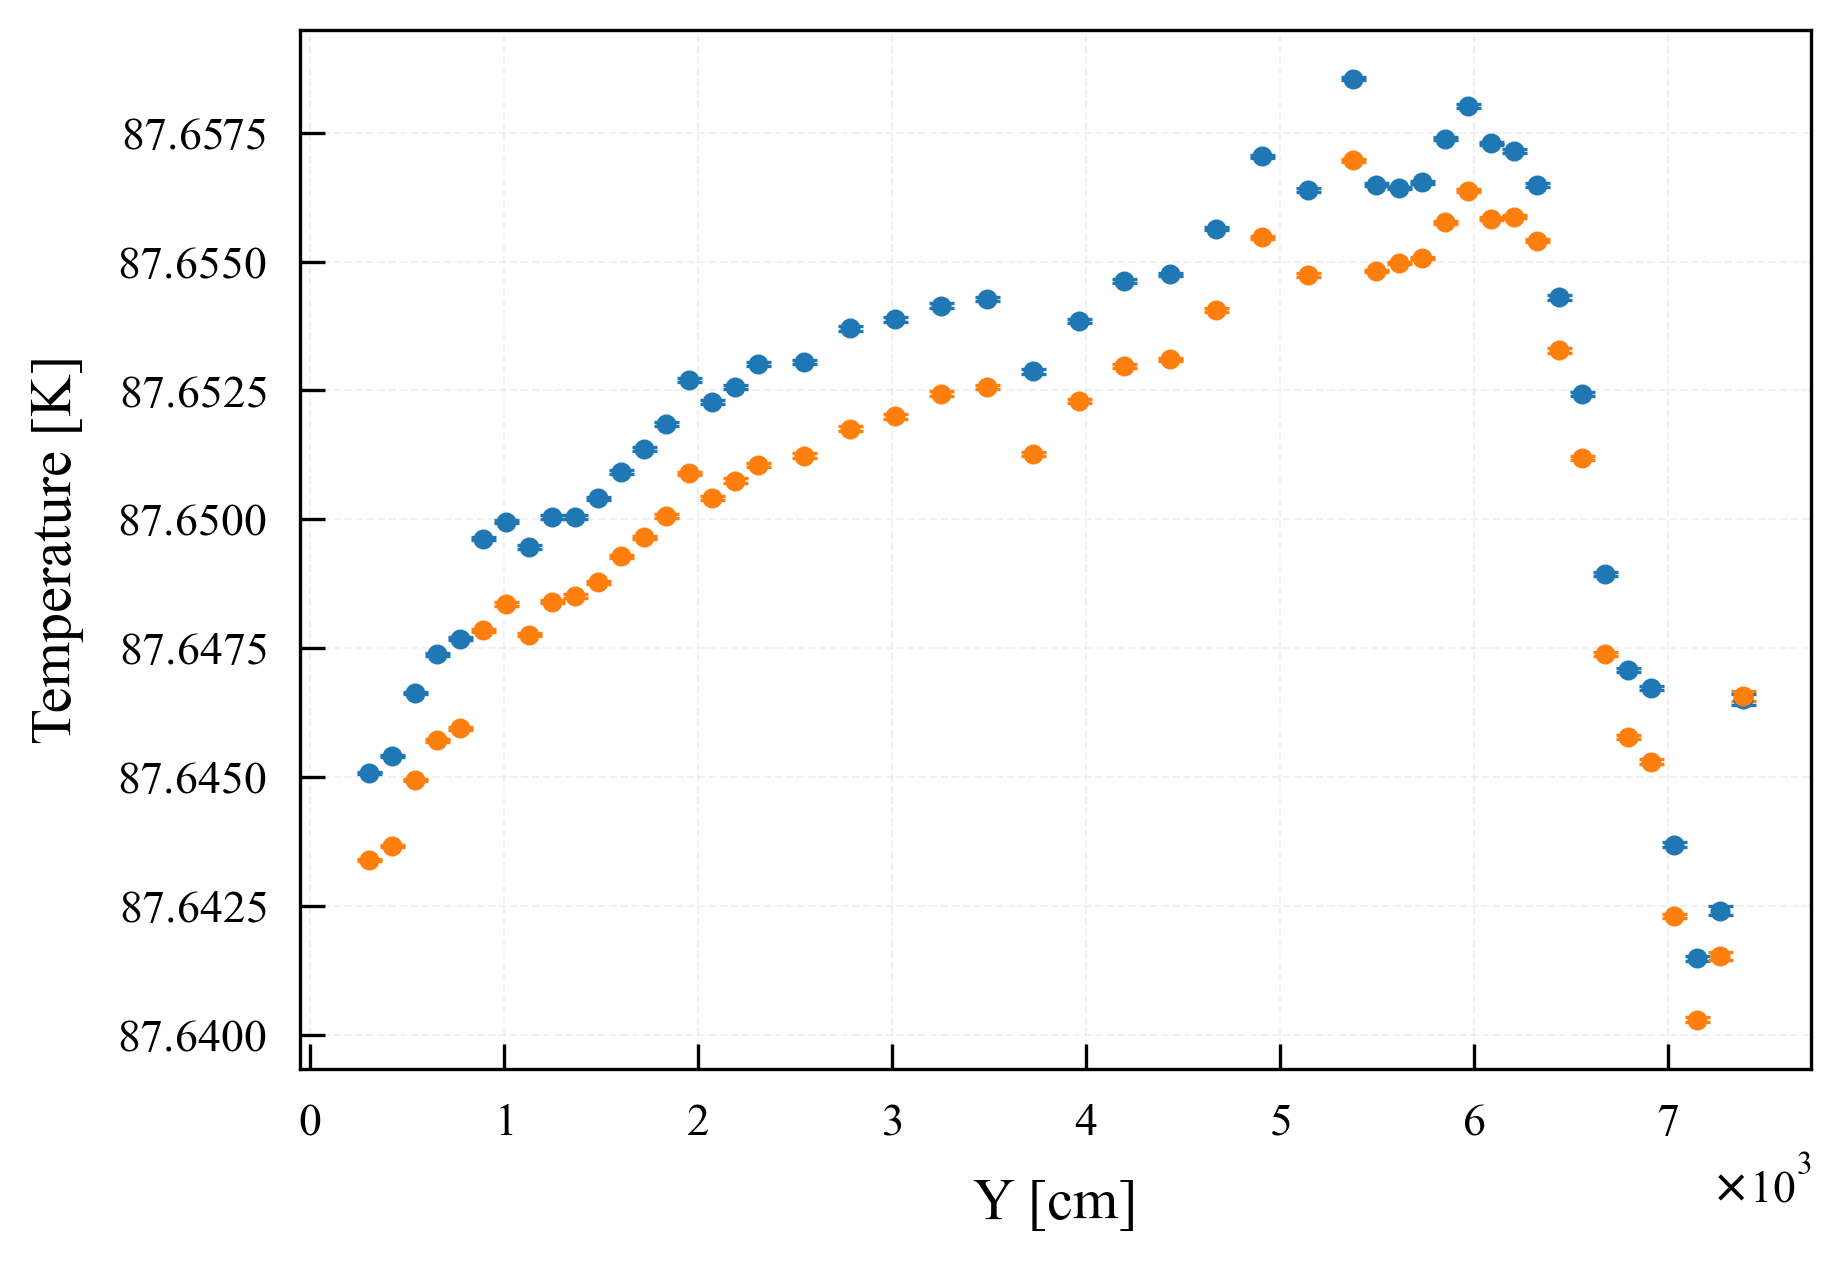

In [35]:
fig, axes = plt.subplots(1,1)
tgrad_before = tgrad.makeProfiles(tini=datetime.datetime(2024, 9, 21), tend=datetime.datetime(2024, 9, 23))
axes.errorbar(tgrad_before.profiles["Y"].values, tgrad_before.profiles["temp"].values, yerr=tgrad_before.profiles["err"].values, marker="o", linestyle="None", color="tab:blue", label="Before")
tgrad_after = tgrad.makeProfiles(tini=datetime.datetime(2024, 9, 24), tend=datetime.datetime(2024, 9, 26))
axes.errorbar(tgrad_after.profiles["Y"].values, tgrad_after.profiles["temp"].values, yerr=tgrad_after.profiles["err"].values, marker="o", linestyle="None", color="tab:orange", label="After")
axes.set_xlabel("Y [cm]")
axes.set_ylabel("Temperature [K]")

<ErrorbarContainer object of 3 artists>

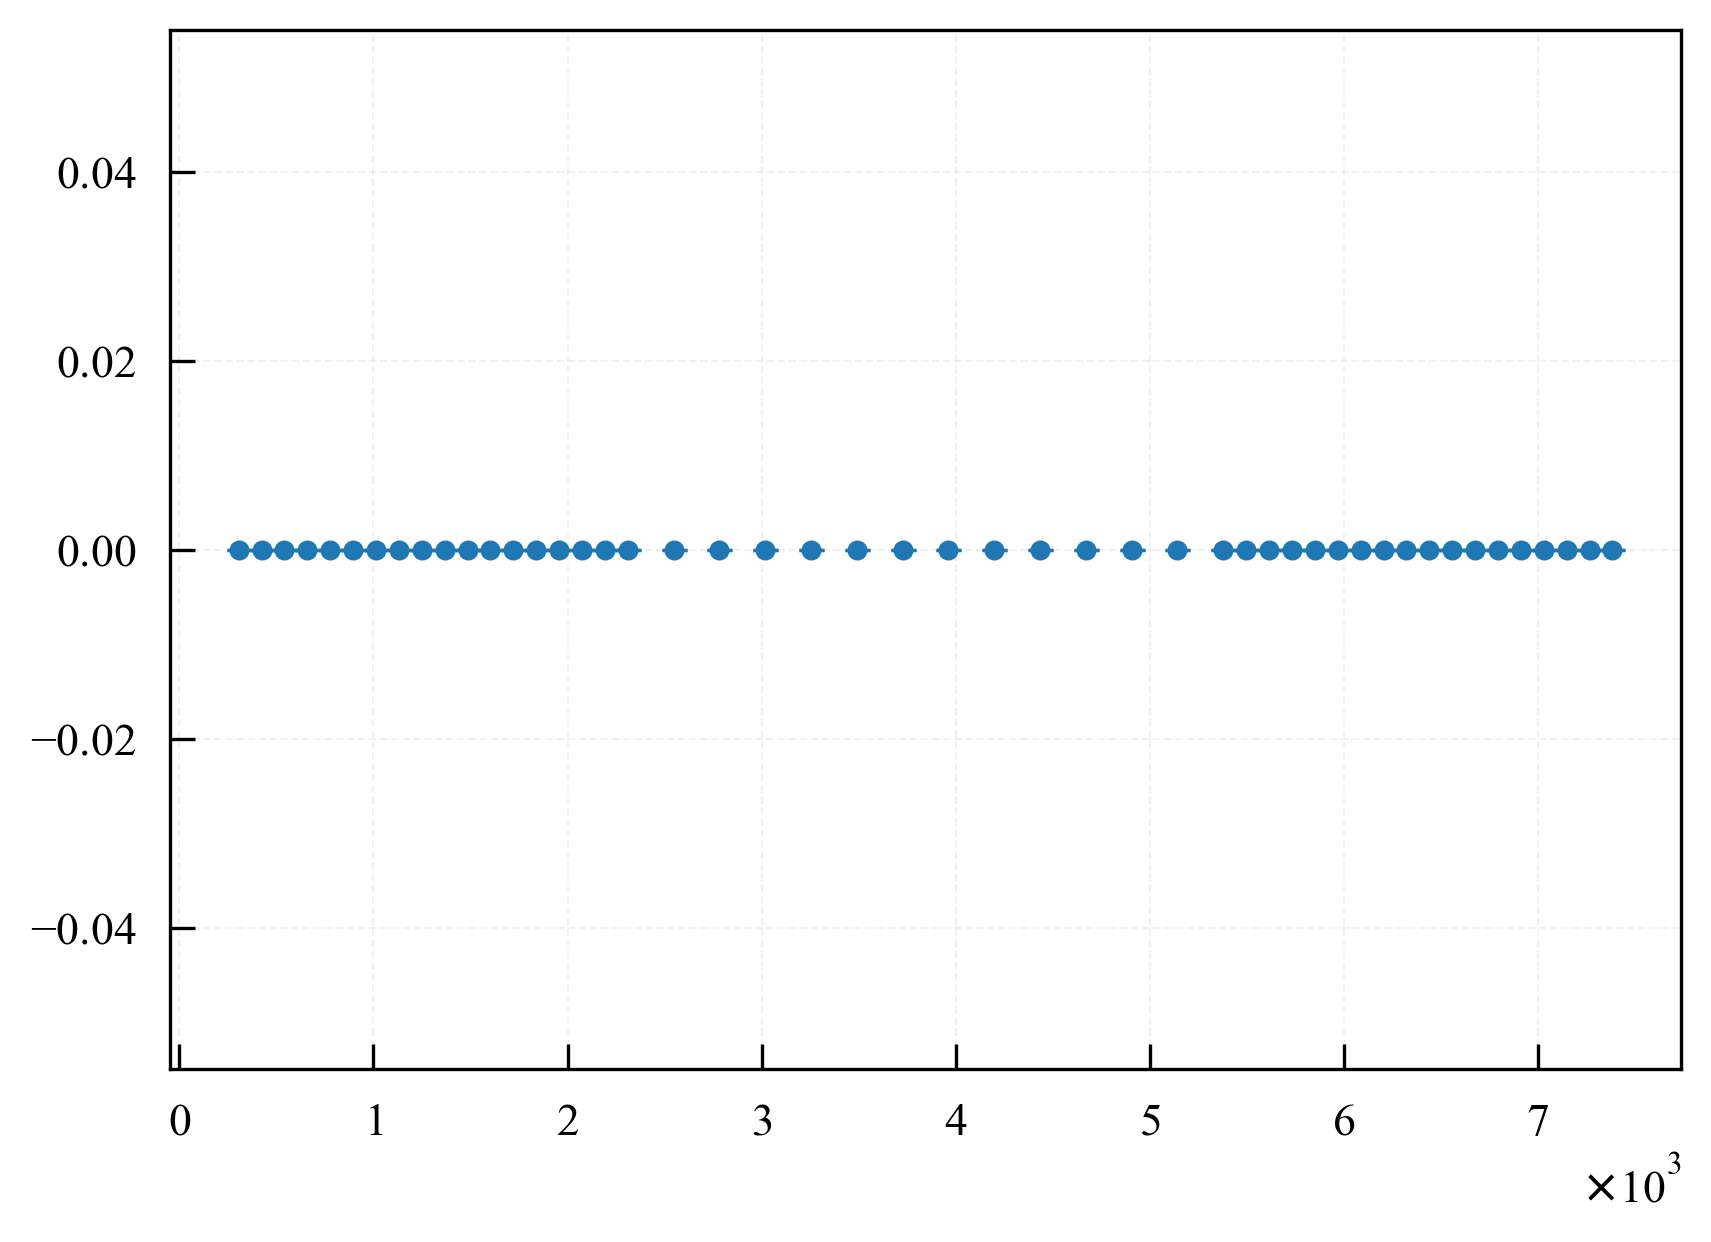

In [37]:
fig, axes = plt.subplots(1,1)
axes.errorbar(
    (tgrad_before.profiles["Y"].values),
    (tgrad_after.profiles["temp"].values - tgrad_before.profiles["temp"].values),
    yerr=0,
    marker="o", linestyle="None"
)

In [18]:
tgrad_stab = tgrad.profile_rms_vs_reference(deltat=5)

Calculating TGRAD temperature profiles every 5 minutes: : 8640step [02:38, 54.42step/s]                      


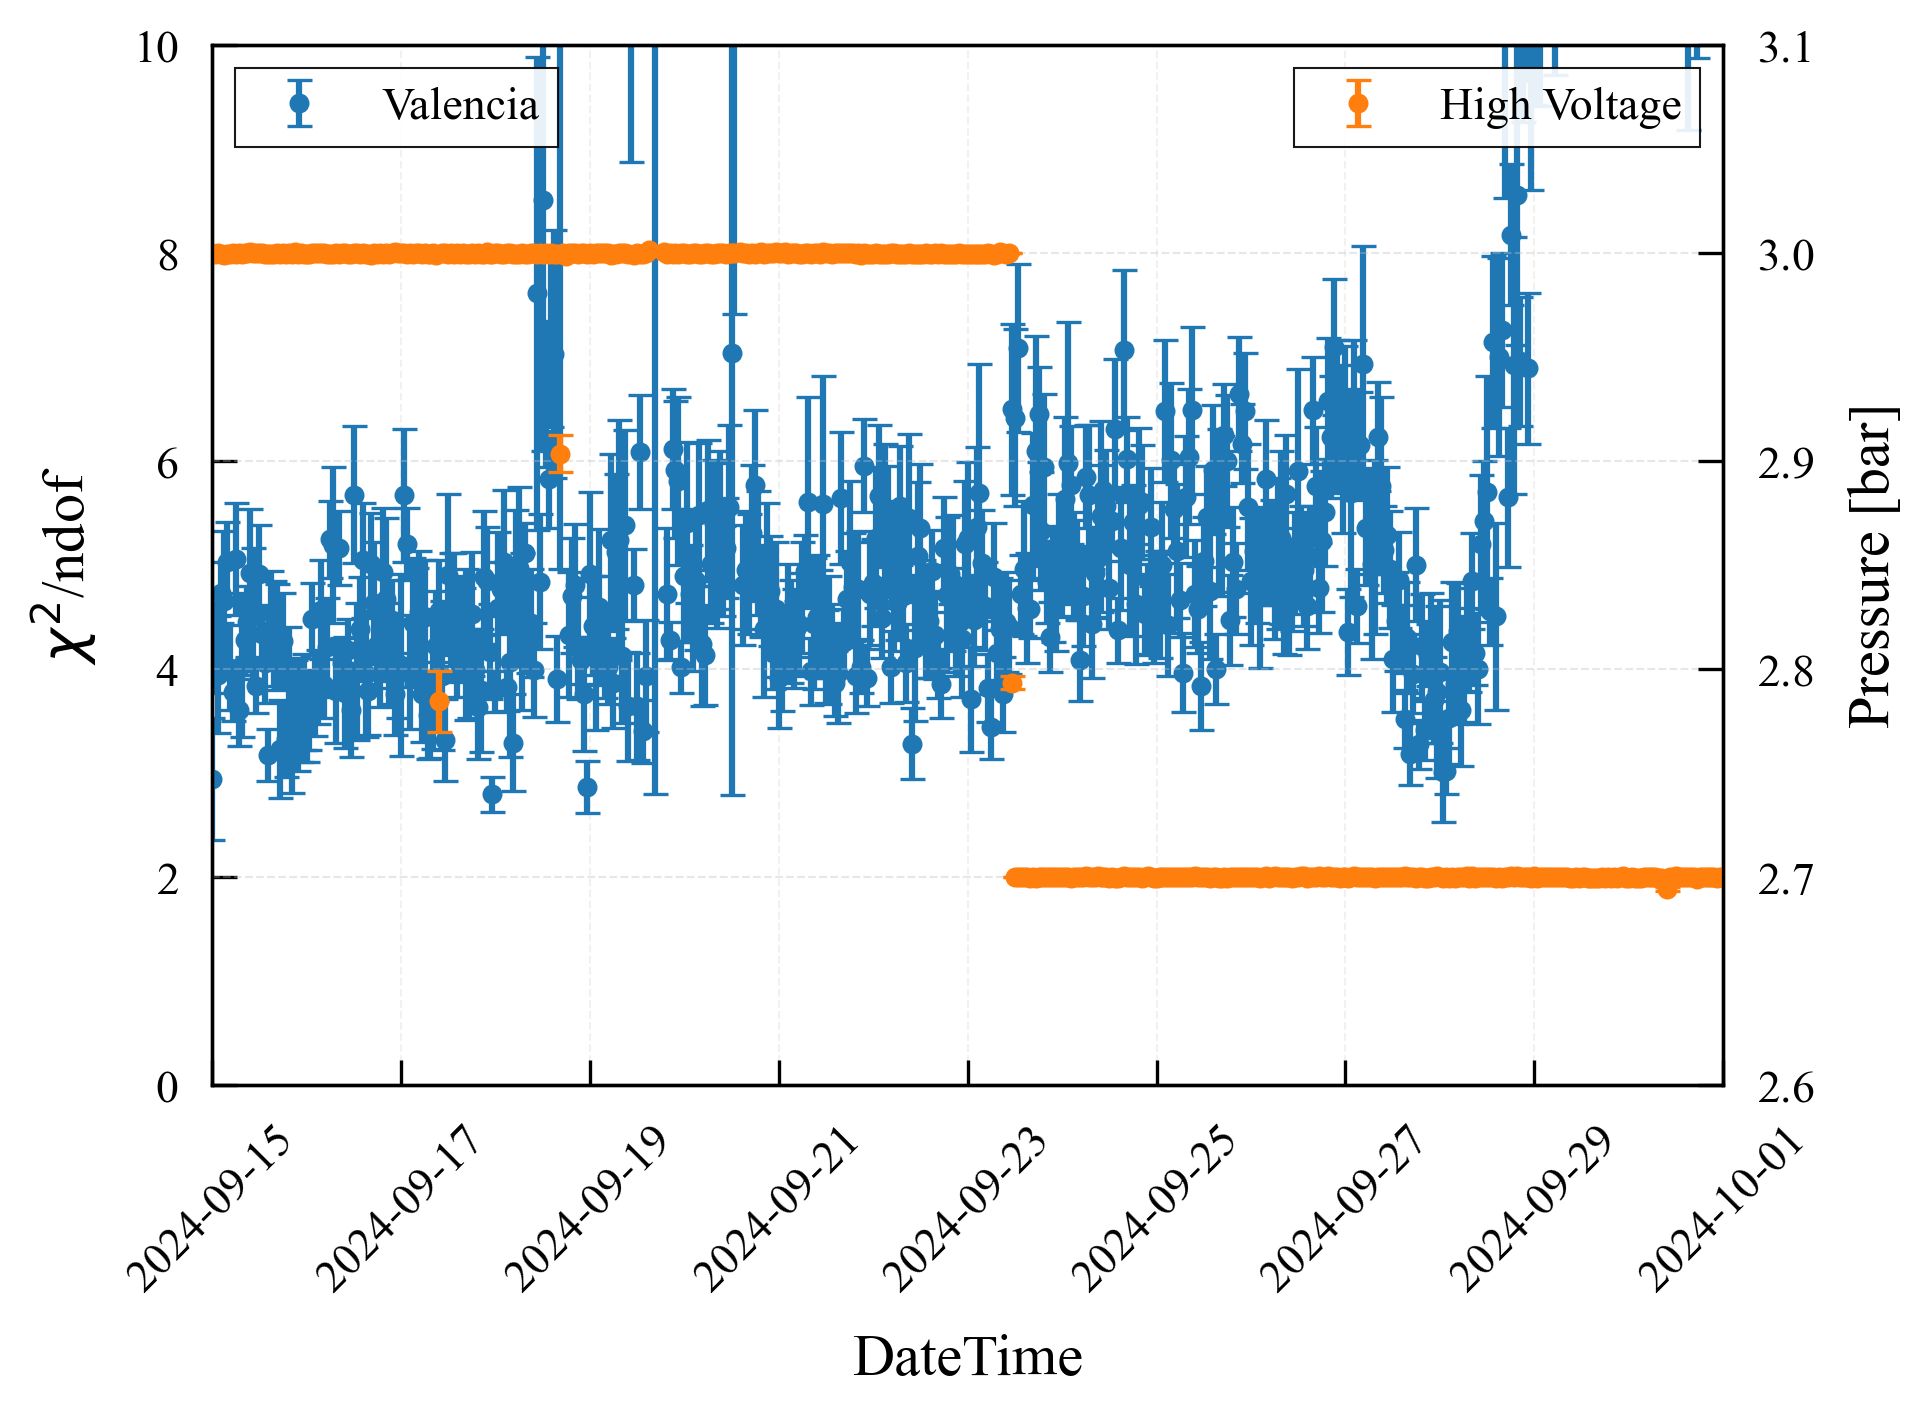

In [ ]:
fig, axes = plt.subplots(1,1)
axes2 = axes.twinx()
axes.errorbar(tgrad.stability.resample("45min").mean().index.values, tgrad.stability.resample("45min").mean()["chi2_ndof"].values, yerr=tgrad.stability.resample("45min").sem()["chi2_ndof"].values, marker="o", linestyle="None", label="Valencia")
axes2.errorbar(pump_diff.data.resample("45min").mean().index.values, pump_diff.data.resample("45min").mean().values, yerr=pump_diff.data.resample("45min").std().values/np.sqrt(2*(len(pump_diff.data.resample("45min").mean())-1)), marker="o", linestyle="None", color="tab:orange", label="High Voltage")
axes.set_xlabel("DateTime")
axes.set_ylabel(fr"$\chi^2$/ndof")
axes.set_ylim(0, 10)
axes.set_xlim(datetime.datetime(2024, 9, 15), datetime.datetime(2024, 10, 1))
axes2.set_ylim(2.6, 3.1)
axes2.set_ylabel("Pressure [bar]")
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
axes.tick_params(axis="x", rotation=45)